In [1]:

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

import pyarrow


In [2]:
#load data
df = pd.read_parquet(Path("fietstellingen_clean.parquet"))
df["start_time"] = pd.to_datetime(df["start_time"])
print(f"bike counts: {len(df):,} rows | {df['site_id'].nunique()} sites")

bike counts: 30,830,936 rows | 150 sites


In [3]:
#df

In [4]:
weather = pd.read_parquet(Path("weather_observed_15min.parquet"))
weather["timestamp"] = pd.to_datetime(weather["timestamp"])
print(f"weather: {len(weather):,} rows | {weather['site_id'].nunique()} sites")

weather: 11,900,763 rows | 151 sites


In [5]:
forecast_errors = pd.read_parquet(Path("weather_forecast_errors.parquet"))
error_summary   = pd.read_parquet(Path("weather_forecast_error_summary.parquet"))

In [6]:
total_cyclists = int(df["count"].sum())
unique_sites = df["site_id"].nunique()
unique_munic = df["municipality"].nunique()
date_min = df["start_time"].min().date()
date_max = df["start_time"].max().date()
missing_pct = round(100 * df["count"].isna().mean(), 2)

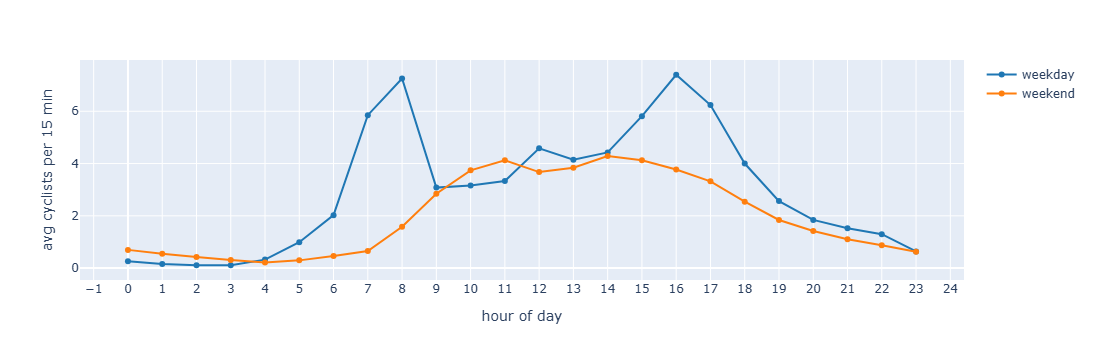

In [7]:
hourly = (
        df.groupby(["hour", "is_weekend"])["count"]
        .mean()
        .reset_index()
)
hourly["day_type"] = hourly["is_weekend"].map({True: "weekend", False: "weekday"})

fig = px.line(
    hourly, x="hour", y="count", color="day_type",
    markers=True,
    labels={"hour": "hour of day", "count": "avg cyclists per 15 min", "day_type": ""},
    color_discrete_map={"weekday": "#1f77b4", "weekend": "#ff7f0e"},
)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1), hovermode="x unified")
fig

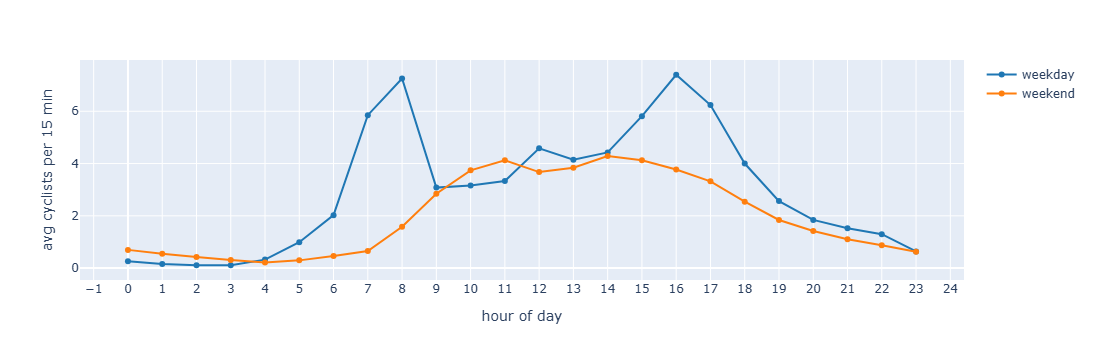

In [8]:
fig

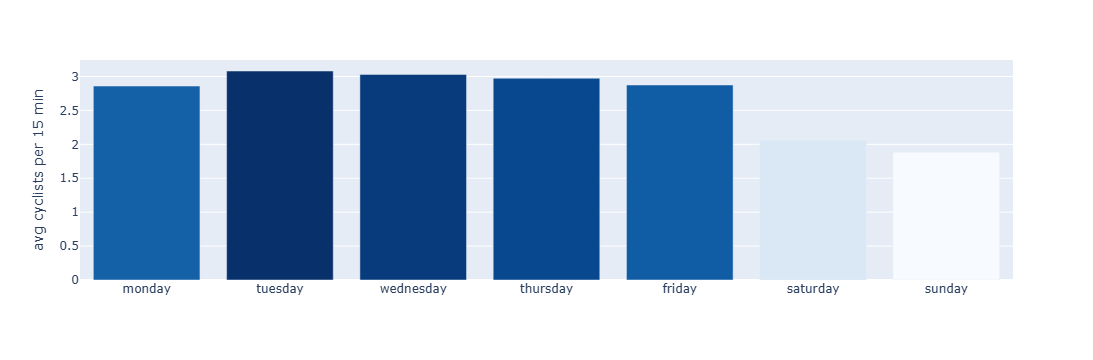

In [9]:
day_names = {0: "monday", 1: "tuesday", 2: "wednesday", 3: "thursday", 4: "friday", 5: "saturday", 6: "sunday"}
daily = df.groupby("day_of_week")["count"].mean().reset_index()
daily["day"] = daily["day_of_week"].map(day_names)
fig_daily = px.bar(
    daily, x="day", y="count",
    labels={"day": "", "count": "avg cyclists per 15 min"},
    color="count", color_continuous_scale="blues",
    category_orders={"day": list(day_names.values())},
)
fig_daily.update_layout(coloraxis_showscale=False)

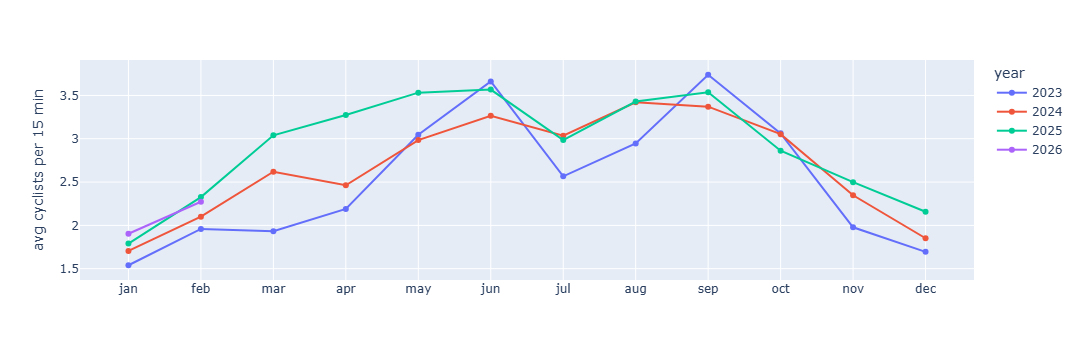

In [10]:
month_labels = {1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}
monthly = df.groupby(["year","month"])["count"].mean().reset_index()
monthly["year"] = monthly["year"].astype(str)
fig = px.line(
    monthly, x="month", y="count", color="year",
    markers=True,
    labels={"month": "", "count": "avg cyclists per 15 min", "year": "year"},)
fig.update_layout(
    xaxis=dict(tickmode="array",
    tickvals=list(month_labels.keys()),
    ticktext=list(month_labels.values())),
    hovermode="x unified",
)
fig

In [11]:
day_short = {0:"mon",1:"tue",2:"wed",3:"thu",4:"fri",5:"sat",6:"sun"}
pivot = (
        df.groupby(["day_of_week","hour"])["count"]
        .mean()
        .unstack()
)
pivot.index = [day_short[i] for i in pivot.index] 
fig = px.imshow(
        pivot,
        labels={"x": "hour of day", "y": "", "color": "avg cyclists"},
        color_continuous_scale="blues", aspect="auto",
)

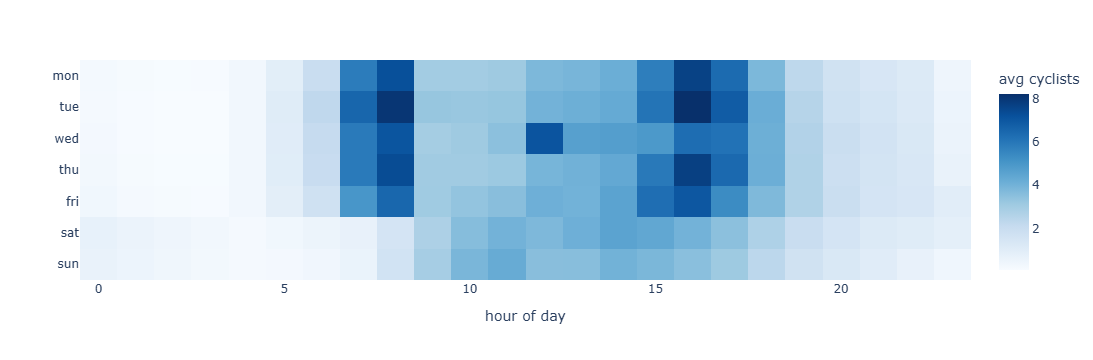

In [12]:
fig

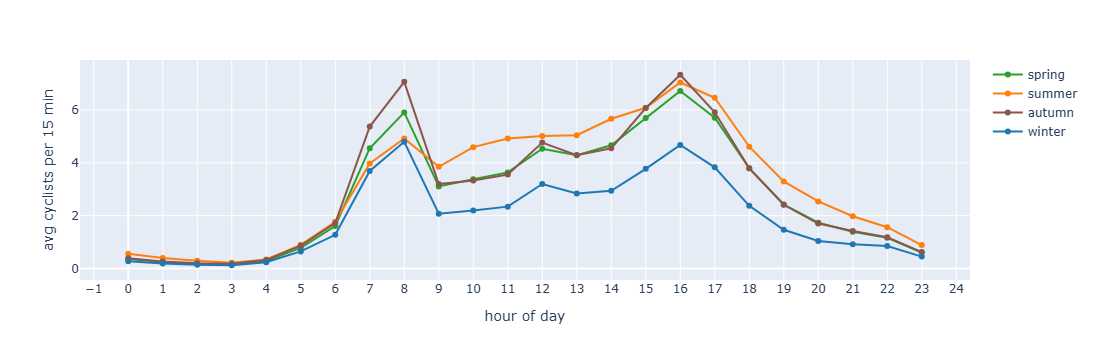

In [13]:
season_map = {12:"winter",1:"winter",2:"winter",3:"spring",4:"spring",5:"spring",6:"summer",7:"summer",8:"summer",9:"autumn",10:"autumn",11:"autumn"}
df_s = df.copy()
df_s["season"] = df_s["month"].map(season_map)
seasonal = df_s.groupby(["season","hour"])["count"].mean().reset_index()
fig = px.line(
        seasonal, x="hour", y="count", color="season",
        markers=True,
        labels={"hour":"hour of day","count":"avg cyclists per 15 min","season":""},
        color_discrete_map={"spring":"#2ca02c","summer":"#ff7f0e",
                            "autumn":"#8c564b","winter":"#1f77b4"},
        category_orders={"season":["spring","summer","autumn","winter"]},
)
fig.update_layout(xaxis=dict(tickmode="linear", dtick=1), hovermode="x unified")
fig

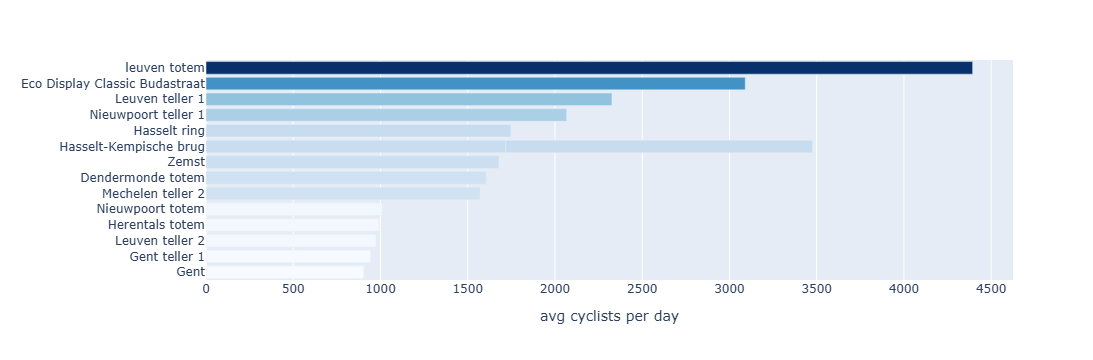

In [14]:
n_days = df["start_time"].dt.date.nunique()
top = (
        df.groupby(["site_id","site_name","municipality"])["count"]
        .sum().reset_index()
)
top["daily_avg"] = top["count"] / n_days
top = top.nlargest(15, "daily_avg")
fig = px.bar(
        top.sort_values("daily_avg"),
        x="daily_avg", y="site_name", orientation="h",
        labels={"daily_avg":"avg cyclists per day","site_name":""},
        color="daily_avg", color_continuous_scale="blues",
)
fig.update_layout(coloraxis_showscale=False)
fig

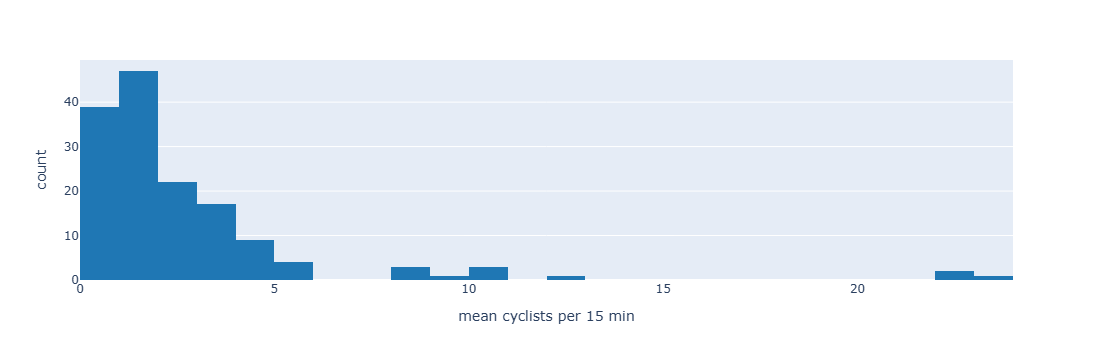

In [15]:
site_avg = (
    df.groupby(["site_id","site_name"])["count"]
    .mean().reset_index()
    .rename(columns={"count":"mean_15min_count"})
)
fig = px.histogram(
    site_avg, x="mean_15min_count", nbins=30,
    labels={"mean_15min_count":"mean cyclists per 15 min"},
    color_discrete_sequence=["#1f77b4"],
)
fig

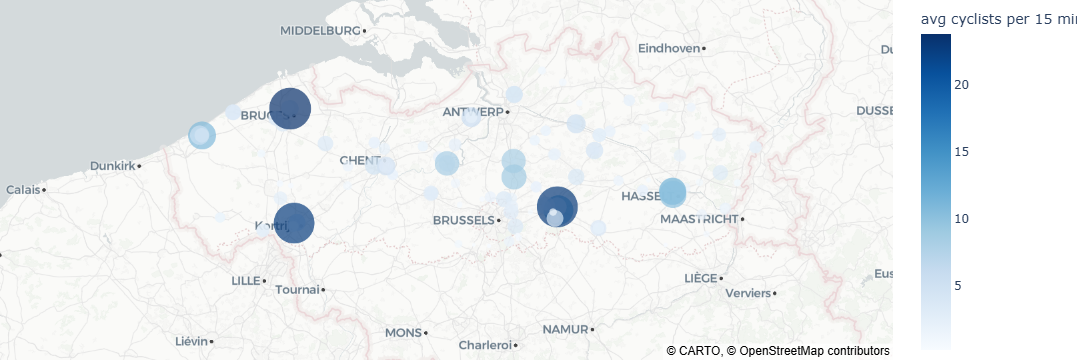

In [16]:
site_map = (
        df.groupby(["site_id","site_name","municipality","lat","lon"])["count"]
        .mean().reset_index()
        .rename(columns={"count":"avg_count"})
        .dropna(subset=["lat","lon","avg_count"])
)
fig = px.scatter_map(
        site_map, lat="lat", lon="lon",
        size="avg_count", color="avg_count",
        hover_name="site_name",
        hover_data={"municipality":True,"avg_count":":.1f","lat":False,"lon":False},
        color_continuous_scale="blues", size_max=30,
        zoom=7, center={"lat":50.98,"lon":4.1},
        map_style="carto-positron",
        labels={"avg_count":"avg cyclists per 15 min"},
    )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig